## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Anh Bach]

**Date:** [9/30/2026]

**Q1 Answers**
1. Regression predicts a numeric target while classification predicts a categorical target. For example, regression can predict the price of an apple based on its size, while classification can predict whether an apple has gone bad based on its color.

2. A confusion matrix counts predictions by actual class and predicted class. The diagonal cells are correct predictions and the off-diagonal cells are misclassifications, so it shows which classes the model gets wrong. It helps us understand accuracy, which is the number of correct predictions from the diagonal divided by the total number of observations.

3. SSE quantifies the total prediction error of a model. It adds up the squared residuals, where a residual is the observed value minus the predicted value. A lower SSE means the predictions are closer to the actual values.

4. Overfitting is when a model fits noise in the training data, so it does well on the training data but poorly on new data. A very small k can overfit. Underfitting is when a model is too simple and gives nearly the same prediction for every observation. A very large k can underfit.

5. Splitting the data lets us fit each model on the training set and measure its error on a test set that was not used to fit the model. We can compare different values of k using a validation set and choose the value with the lowest error or highest accuracy. This helps avoid both overfitting from a very small k and underfitting from a very large k. Training error alone would usually favor a very small k, so validation helps us choose a model that performs better on new data. After k is selected, a separate test set can be used for the final evaluation.

6. A class label gives one clear answer, so it is easy to use and easy to check with accuracy, but it hides how confident the model is of its prediction. A probability distribution shows the share of neighbors in each class, so we can see how confident the model is of its prediction. However, probabilities are more complicated to interpret, meaning a reported probability does not always correspond exactly to the true chance of that outcome.

In [1]:
# Your Phase 1 solution to the problem goes here.
#Q2-1 Answers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/land_mines.csv")
features = ["voltage", "height", "soil"]

print(f"{len(df)} observations; {df['mine_type'].nunique()} mine types")
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

338 observations; 5 mine types
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
0


In [2]:
print(df["mine_type"].value_counts().sort_index())
print(df["mine_type"].value_counts(normalize=True).sort_index().round(3))

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_type
1    0.210
2    0.207
3    0.195
4    0.195
5    0.192
Name: proportion, dtype: float64


In [3]:
print(df[features].describe().round(3))
print(df[features].agg(["min", "max"]).round(3))

       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000
     voltage  height  soil
min    0.198     0.0   0.0
max    1.000     1.0   1.0


In [4]:
print(df.groupby("mine_type")[features].mean().round(3))

           voltage  height   soil
mine_type                        
1            0.296   0.496  0.493
2            0.721   0.487  0.509
3            0.402   0.528  0.497
4            0.345   0.507  0.503
5            0.380   0.530  0.517


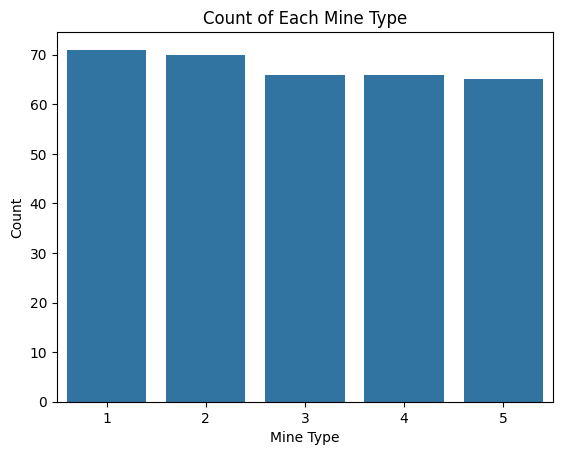

In [5]:
sns.countplot(data=df, x="mine_type")
plt.title("Count of Each Mine Type")
plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.show()

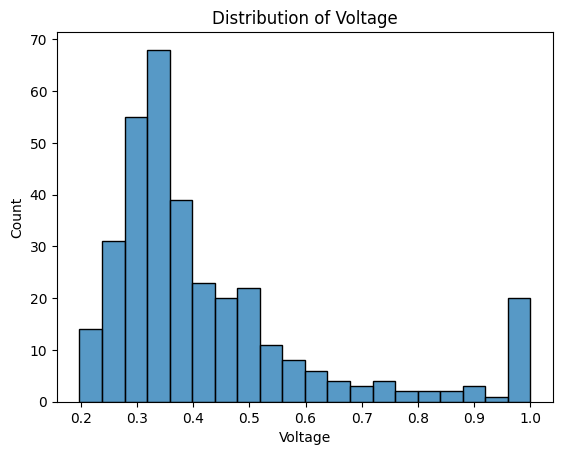

In [6]:
sns.histplot(data=df, x="voltage", bins=20)
plt.title("Distribution of Voltage")
plt.xlabel("Voltage")
plt.ylabel("Count")
plt.show()

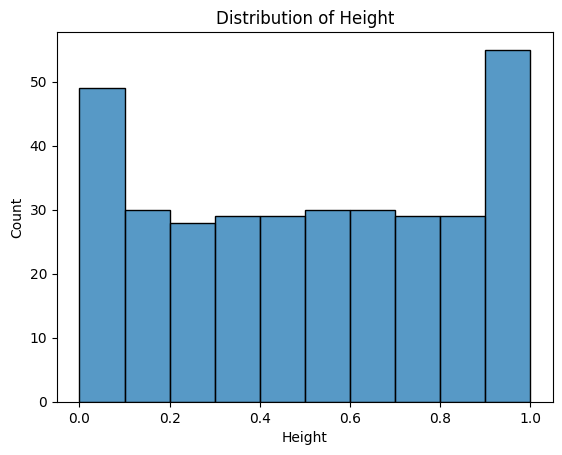

In [7]:
sns.histplot(data=df, x="height", bins=10)
plt.title("Distribution of Height")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

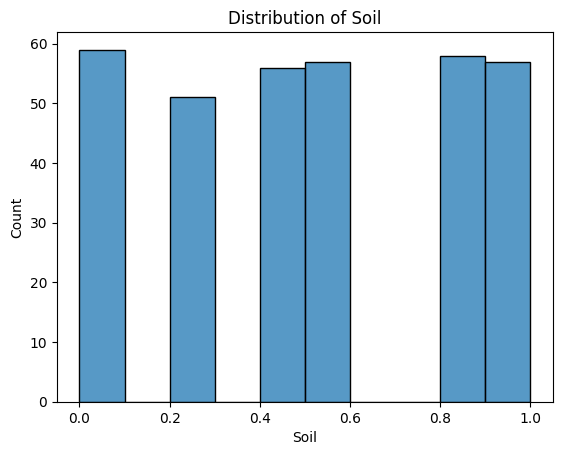

In [8]:
sns.histplot(data=df, x="soil", bins=10)
plt.title("Distribution of Soil")
plt.xlabel("Soil")
plt.ylabel("Count")
plt.show()

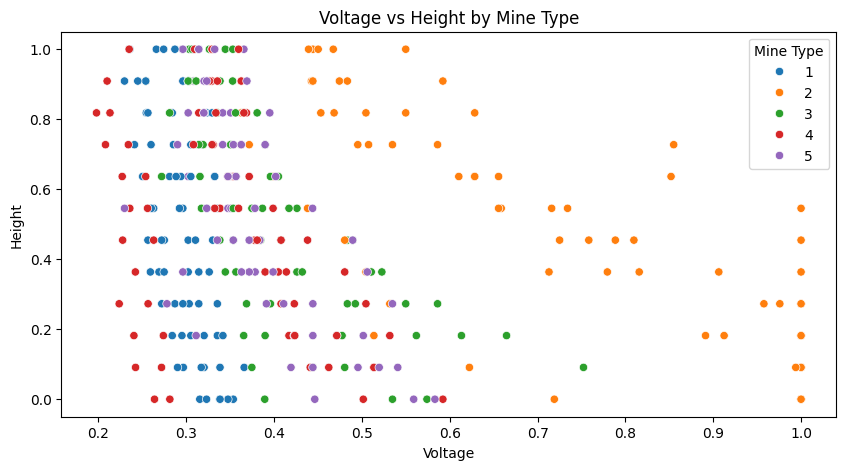

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="voltage",
    y="height",
    hue=df["mine_type"].astype(str),
    hue_order=["1", "2", "3", "4", "5"],
)
plt.title("Voltage vs Height by Mine Type")
plt.xlabel("Voltage")
plt.ylabel("Height")
plt.legend(title="Mine Type")
plt.show()

The data has 338 mines in 5 balanced types of around 65 to 71 each, with no missing values or duplicates. All three features (voltage, height, soil) are already between 0 and 1, and soil and height only take a few distinct values. Mine type 2 has the highest voltages, while the other types overlap a lot, so some of them will be hard to tell apart.

In [10]:
#Q2-2 Answers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df[features]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)
print(len(X_train), len(X_test))
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

169 169
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


In [11]:
#Q2-3 Answers
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    candidate = KNeighborsClassifier(n_neighbors=k)
    candidate.fit(X_train_scaled, y_train)
    train_hat = candidate.predict(X_train_scaled)
    test_hat = candidate.predict(X_test_scaled)
    train_acc.append(np.sum(y_train.to_numpy() == train_hat) / len(y_train))
    test_acc.append(np.sum(y_test.to_numpy() == test_hat) / len(y_test))

best_k = int(ks[np.argmax(test_acc)])
print("Best k:", best_k)
print("Test accuracy at best k:", round(max(test_acc), 3))

Best k: 1
Test accuracy at best k: 0.462


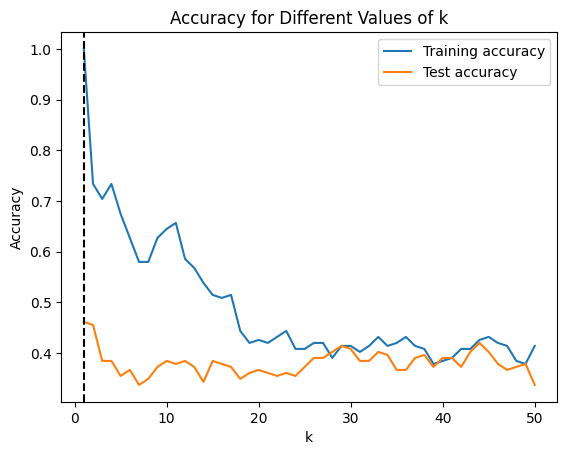

In [12]:
plt.plot(ks, train_acc, label="Training accuracy")
plt.plot(ks, test_acc, label="Test accuracy")
plt.axvline(best_k, linestyle="--", color="black")
plt.title("Accuracy for Different Values of k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

I tried every k from 1 to 50. For each k, I fit the model on the training set and measured accuracy on the validation set. I selected the k with the highest validation accuracy, which was k = 1 with an accuracy of 0.462. Accuracy for k = 1 and k = 2 is very similar, and accuracy generally decreases as k becomes larger.

In [13]:
#Q2-4 Answers
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print(pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"]))

accuracy = np.sum(y_test.to_numpy() == y_pred) / len(y_test)
print("Accuracy:", round(accuracy, 3))

Predicted   1   2  3   4  5
Actual                     
1          21   0  4   4  7
2           0  32  0   3  0
3           8   0  7  10  8
4           7   5  4  11  6
5           7   0  9   9  7
Accuracy: 0.462


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.49      0.58      0.53        36
           2       0.86      0.91      0.89        35
           3       0.29      0.21      0.25        33
           4       0.30      0.33      0.31        33
           5       0.25      0.22      0.23        32

    accuracy                           0.46       169
   macro avg       0.44      0.45      0.44       169
weighted avg       0.45      0.46      0.45       169



The model gets 78 of 169 test mines right, so accuracy is 46.2%. Random guessing would be around 20%, so the model is better than guessing but not good overall. It works best for type 2, where 32 of 35 are correct with 91% recall and 86% precision. The model does worst on types 3 and 5, which are only right about 21% to 22% of the time, and type 4 is right about 33% of the time. Type 1 is in the middle, with about 58% of actual type 1 mines found. As such, the model mixes up types 1, 3, 4 and 5, but appears to be quite good at predicting type 2.

Q2-5 Answers: The model performs a lot better when predicting type 2 than the other classes since the model finds 32 of the 35 actual type 2 mines and is right about 87% of the time when it predicts type 2. Predictions of type 1, 3, 4, or 5 are much less reliable. For example, when the model predicts type 3, it is right only about 29% of the time. For type 1, the model finds about 58% of the actual type 1 mines, but it is right only about 49% of the time when it predicts type 1, so there are many incorrect predictions. For practical use, I would use the model as a first screening tool when exploring a minefield. Predictions for types 1, 3, 4, and 5 should be treated as uncertain and followed by additional expert inspection. Given the overall accuracy of only 46.2%, the model should not be relied on by itself for decisions.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [732ee00bf18cad7ea8b9146d398a5411188567ea]
- **AI tool and model used:** [GPT-5.6 Sol]

### *Prompts used

1. [attached notebook] please check through my notebook at see if there are any changes that I need to make to answer the questions correctly or if there are any problems with my code based on the requirements for the questions
2. [attached notebook and pasted rubric] Are the changes good to go to submit?

### *AI-proposed changes


1. I went through the full notebook, including every markdown/code cell and the saved outputs. Your Phase 1 is fundamentally correct, and I do not see any code error that changes your reported results. Your 46.2% accuracy, confusion table interpretation, and discussion of mine type 2 versus types 3–5 are all consistent with the output.
There are a few changes I would make before submission, though.
Changes I would make
1. Revise Q1 #4 slightly. Your overfitting definition is good, but your underfitting definition is a little too narrow:
“Underfitting is when a model is too simple and gives nearly the same prediction for every observation.”

Underfitting does not necessarily mean nearly identical predictions. A more correct version would be:
Underfitting is when a model is too simple to capture the important patterns in the data, so it performs poorly even on the training data and usually also performs poorly on new data. In k-NN, a very large \(k\) can cause underfitting because predictions become overly smoothed.

This is the conceptual change I would consider most important.
2. Clarify Q1 #5 because your terminology conflicts slightly with Q2. You correctly wrote that ideally you use training → validation → test. But the assignment specifically tells you to make a 50/50 training and test/validation split and use that second set to choose \(k\). Your Q2 code follows the assignment.
I would phrase Q1 #5 more like:
Splitting the data allows us to fit models on the training set and evaluate them on observations that were not used to fit the model. We can compare different values of \(k\) on a validation set and choose the one with the highest accuracy or lowest SSE. This helps avoid choosing a model simply because it performs well on the training data. Ideally, a separate test set would then be used for a final unbiased evaluation.

That keeps the statistical distinction clear without suggesting your Q2 implementation is wrong.
3. Q1 #6 is correct, but one extra point would make it stronger. You say probabilities show confidence, which is generally reasonable, but for k-NN the probabilities are based on the proportion of neighbors in each class. That means they can be fairly coarse. With your final model, \(k=1\), predicted probabilities would essentially be 0 or 1, which should definitely not be interpreted as true 0%/100% certainty.
You could add:
For k-NN, these probabilities are based on the proportion of nearby neighbors in each class, so they may not be well calibrated. With very small \(k\), especially \(k=1\), the probabilities can appear much more certain than the model really is.

Your Q2 code
Q2-1: EDA — good. You correctly check dataset size, class balance, descriptive statistics, missing values, duplicates, distributions, class-specific means, and a relationship between features.
There is only one small inconsistency. You write:
“soil and height only take a few distinct values”

but you never actually print the number of distinct values. The histograms suggest it, but I would explicitly demonstrate it:
print(df[features].nunique())


Then that sentence is directly supported by your EDA.
Also change:
print(df.info())


to:
df.info()


because df.info() already prints its result. Your current version produces that unnecessary None at the bottom.
Neither of these affects correctness.
Q2-2: 50/50 split — correct
This part is done very well:
X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.50, random_state=42, stratify=y)


Using stratify=y is especially appropriate because the assignment explicitly warns about classes accidentally becoming uneven between the two sets.
Your resulting split also confirms that every class is well represented:
- Training: 35, 35, 33, 33, 33
- Test/validation: 36, 35, 33, 33, 32
No change needed.
Scaling — your code is valid
You use:
scaler = MinMaxScaler()X_train_scaled = scaler.fit_transform(X_train)X_test_scaled = scaler.transform(X_test)


This is correct. Importantly, you fit the scaler only on the training data, which avoids data leakage.
Since the original variables are already roughly 0–1, scaling will not dramatically change them, although it does stretch voltage from its observed range of 0.198–1.0 to 0–1. I would not change this unless your professor explicitly said not to scale. Scaling is standard practice with k-NN because distance is sensitive to feature scales.
Q2-3: selecting \(k\) — correct for this assignment
Your loop is correct:
for k in ks:    candidate = KNeighborsClassifier(n_neighbors=k)    candidate.fit(X_train_scaled, y_train)    train_hat = candidate.predict(X_train_scaled)    test_hat = candidate.predict(X_test_scaled)


and:
best_k = int(ks[np.argmax(test_acc)])


correctly chooses the \(k\) with highest held-out accuracy.
You found:
Best \(k=1\), validation accuracy = 0.462

That is consistent with your later confusion matrix.
One terminology improvement: because you're using this second dataset to choose \(k\), I would call it the validation set in your writing rather than repeatedly calling it the test set. The assignment itself says “test/validation,” so your current code is not wrong.
You could even rename variables to X_val, y_val, but that is optional and would require changing several cells.
Q2-3 explanation — good
Your explanation:
“I tried every k from 1 to 50... selected the k with the highest validation accuracy...”

directly answers “Explain how you select \(k\).”
I would keep it.
You could make one tiny wording change:
“Accuracy for \(k=1\) and \(k=2\) is very similar...”

If the plot clearly shows that, it is fine. Don't say they are tied unless they actually have identical accuracy.
Q2-4: confusion table — correct
Your table is correct, and your total is correct:
\[
21+32+7+11+7=78
\]
so
\[
78/169\approx0.4615=46.2\%.
\]
Your interpretation is also accurate:
- Type 1 recall: \(21/36=58.3\%\)
- Type 2 recall: \(32/35=91.4\%\)
- Type 3 recall: \(7/33=21.2\%\)
- Type 4 recall: \(11/33=33.3\%\)
- Type 5 recall: \(7/32=21.9\%\)
Your statement that type 2 is substantially easier for the model to identify is supported by both precision and recall.
The classification_report was a good addition and isn't required, but strengthens your response.
Q2-5: practical interpretation — good
This is one of the stronger parts of the notebook. You correctly distinguish between:
- Recall: how many actual mines of that type are identified.
- Precision: how often that prediction is actually correct.
Your type 1 example is particularly useful:
58% of actual type 1 mines are identified, but only about 49% of type-1 predictions are actually type 1.

That directly addresses the professor's warning that you can have many correct predictions while still making many mistakes.
Given that this is a safety-critical land-mine scenario, I would slightly strengthen your final sentence:
Given the overall accuracy of only 46.2%, the model should only be used as a preliminary screening tool and should not be used by itself to make safety-critical decisions or determine how a mine should be handled.

Your current answer already basically says this, though, so this is polishing rather than a correction.
One notebook issue you should fix before submitting
Your Q2-3 cell has saved output but its execution count is None, while the surrounding cells have execution counts 10, 12, 13, etc. That can happen if a cell was edited or its execution metadata got altered after running it.
I strongly recommend doing:
Kernel → Restart & Run All
before submitting.
Make sure it produces:
Best k: 1
Test accuracy at best k: 0.462
and the same confusion matrix.

Overall: I would consider your actual statistical/code solution correct. The only conceptual answer I would definitely revise is the definition of underfitting. The other Phase 1 changes are mostly precision and presentation improvements. The major remaining work is completing the required Phase 2 documentation and revised solution.

2. Your actual Q1/Q2 solution is good now. The revised definitions, EDA, split, scaling, \(k\)-selection, confusion matrix, and interpretation are all fine.
You are not quite ready to submit yet because the Phase 2 documentation still has a few incomplete/template pieces:
- AI-proposed changes: replace the long pasted review with the short numbered list of changes only.
- Evaluation table: remove the placeholder row Accept / modify / reject | ... or complete it. Since you grouped the accepted Q1/EDA changes together, one completed row is fine if your instructor does not require one row per suggestion.
- Reflection: you still need to write your own 150–300 word reflection. The notebook explicitly says this must be in your own words without generative AI.
- Remove leftover template text like [Paste the AI's concise numbered list verbatim.].
Your Phase 2 code has also been rerun cleanly from execution counts 15 through 28, and it reproduces the same best \(k=1\) and 46.2% accuracy, so the technical side looks ready.
Once you clean up those Phase 2 placeholders and write your reflection, yes, I would consider it ready to submit.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Revise Q1 definitions and add unique-value counts to the EDA. | Modify |I revised the Q1 definitions to be more specific and accurate, and added unique-value counts to better support the EDA observations. I verified the changes by rerunning the affected cells and confirming that the results and overall conclusions stayed the same.|
| 2. Keep the code, split, scaling, k-selection, confusion matrix, and interpretation unchanged | Accept| After accepting the proposed Phase 1 changes in Phase 2, everything appears to be correct. I verified this by rerunning the notebook and confirming that the model results and conclusions remained consistent. I just need to complete the remaining Phase 2 write-up before submitting. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Q1 Answers**
1. Regression predicts a numeric target while classification predicts a categorical target. For example, regression can predict the price of an apple based on its size, while classification can predict whether an apple has gone bad based on its color.

2. A confusion matrix counts predictions by actual class and predicted class. The diagonal cells are correct predictions and the off-diagonal cells are misclassifications, so it shows which classes the model gets wrong. It helps us understand accuracy, which is the number of correct predictions from the diagonal divided by the total number of observations.

3. SSE quantifies the total prediction error of a model. It adds up the squared residuals, where a residual is the observed value minus the predicted value. A lower SSE means the predictions are closer to the actual values.

4. Overfitting is when a model learns the training data too closely, including noise, so it performs well on training data but poorly on new data. A very small (k) can overfit. Underfitting is when a model is too simple to capture important patterns in the data, causing poor performance on both training and new data. A very large (k) can underfit.

5. Splitting the data lets us fit each model on the training set and measure its error on a test set that was not used to fit the model. We can compare different values of k using a validation set and choose the value with the lowest error or highest accuracy. This helps avoid both overfitting from a very small k and underfitting from a very large k. Training error alone would usually favor a very small k, so validation helps us choose a model that performs better on new data. After k is selected, a separate test set can be used for the final evaluation.

6. A class label gives one predicted category, which is simple to interpret but does not show uncertainty. A probability distribution gives an estimated probability for each class; in k-NN, these probabilities are based on the proportion of neighbors in each class. This gives more information about uncertainty, but the probabilities may not represent the true chance of each outcome.

In [15]:
# Your Phase 2 solution to the problem goes here.
#Q2-1 Answers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/land_mines.csv")
features = ["voltage", "height", "soil"]

print(f"{len(df)} observations; {df['mine_type'].nunique()} mine types")
print(df.head())
df.info()
print(df.isnull().sum())
print(df.duplicated().sum())
print(df[features].nunique())

338 observations; 5 mine types
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
0
voltage    196
height      12
soil         6
dtype: int64


In [16]:
print(df["mine_type"].value_counts().sort_index())
print(df["mine_type"].value_counts(normalize=True).sort_index().round(3))

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_type
1    0.210
2    0.207
3    0.195
4    0.195
5    0.192
Name: proportion, dtype: float64


In [17]:
print(df[features].describe().round(3))
print(df[features].agg(["min", "max"]).round(3))

       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000
     voltage  height  soil
min    0.198     0.0   0.0
max    1.000     1.0   1.0


In [18]:
print(df.groupby("mine_type")[features].mean().round(3))

           voltage  height   soil
mine_type                        
1            0.296   0.496  0.493
2            0.721   0.487  0.509
3            0.402   0.528  0.497
4            0.345   0.507  0.503
5            0.380   0.530  0.517


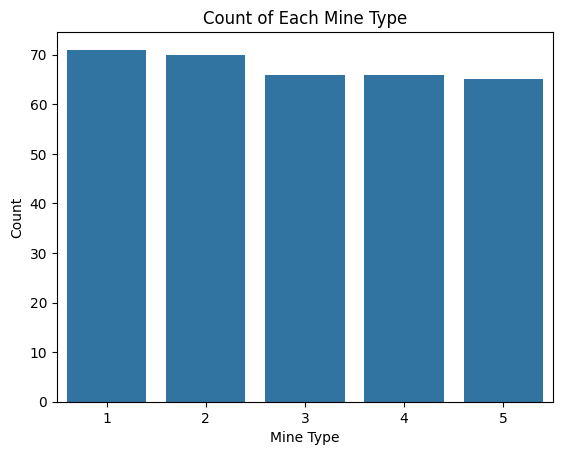

In [19]:
sns.countplot(data=df, x="mine_type")
plt.title("Count of Each Mine Type")
plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.show()

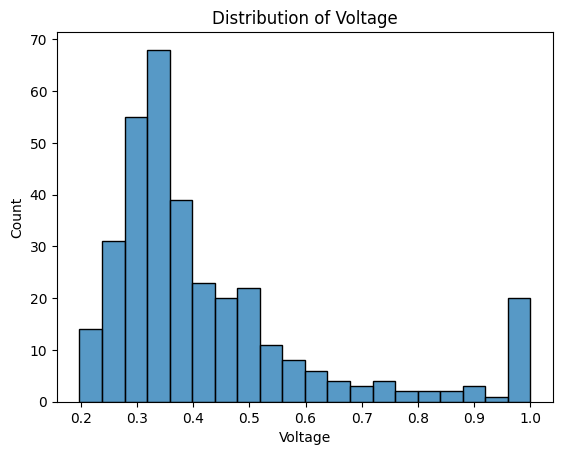

In [20]:
sns.histplot(data=df, x="voltage", bins=20)
plt.title("Distribution of Voltage")
plt.xlabel("Voltage")
plt.ylabel("Count")
plt.show()

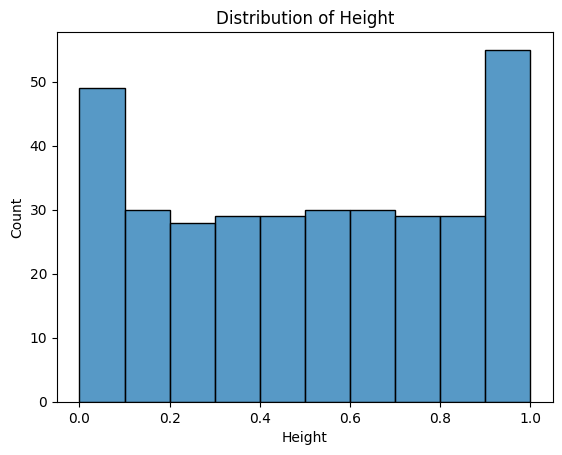

In [21]:
sns.histplot(data=df, x="height", bins=10)
plt.title("Distribution of Height")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

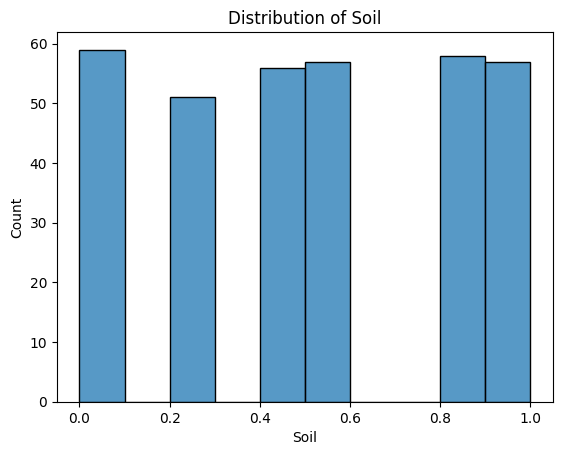

In [22]:
sns.histplot(data=df, x="soil", bins=10)
plt.title("Distribution of Soil")
plt.xlabel("Soil")
plt.ylabel("Count")
plt.show()

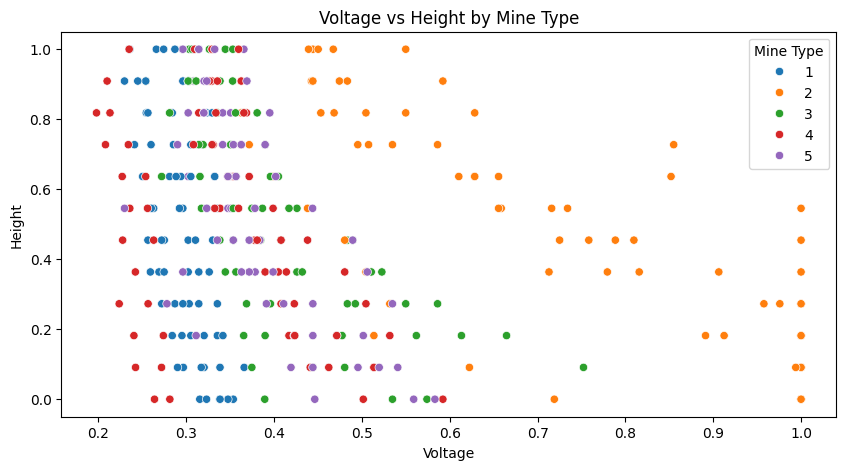

In [23]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="voltage",
    y="height",
    hue=df["mine_type"].astype(str),
    hue_order=["1", "2", "3", "4", "5"],
)
plt.title("Voltage vs Height by Mine Type")
plt.xlabel("Voltage")
plt.ylabel("Height")
plt.legend(title="Mine Type")
plt.show()

The data has 338 mines in 5 balanced types of around 65 to 71 each, with no missing values or duplicates. All three features (voltage, height, soil) are already between 0 and 1, and soil and height only take a few distinct values. Mine type 2 has the highest voltages, while the other types overlap a lot, so some of them will be hard to tell apart.

In [24]:
#Q2-2 Answers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df[features]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)
print(len(X_train), len(X_test))
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

169 169
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


In [25]:
#Q2-3 Answers
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    candidate = KNeighborsClassifier(n_neighbors=k)
    candidate.fit(X_train_scaled, y_train)
    train_hat = candidate.predict(X_train_scaled)
    test_hat = candidate.predict(X_test_scaled)
    train_acc.append(np.sum(y_train.to_numpy() == train_hat) / len(y_train))
    test_acc.append(np.sum(y_test.to_numpy() == test_hat) / len(y_test))

best_k = int(ks[np.argmax(test_acc)])
print("Best k:", best_k)
print("Test accuracy at best k:", round(max(test_acc), 3))

Best k: 1
Test accuracy at best k: 0.462


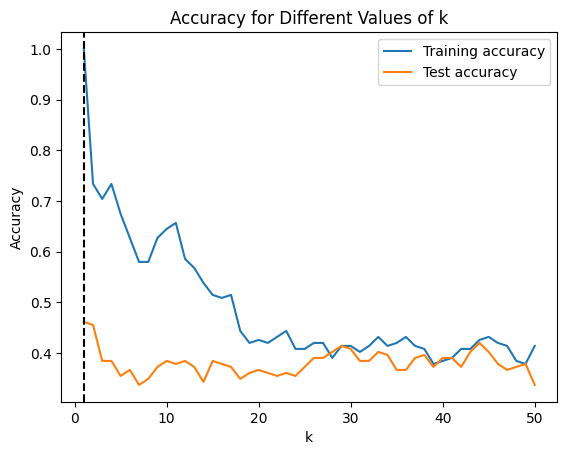

In [26]:
plt.plot(ks, train_acc, label="Training accuracy")
plt.plot(ks, test_acc, label="Test accuracy")
plt.axvline(best_k, linestyle="--", color="black")
plt.title("Accuracy for Different Values of k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

I tried every k from 1 to 50. For each k, I fit the model on the training set and measured accuracy on the validation set. I selected the k with the highest validation accuracy, which was k = 1 with an accuracy of 0.462. Accuracy for k = 1 and k = 2 is very similar, and accuracy generally decreases as k becomes larger.

In [27]:
#Q2-4 Answers
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print(pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"]))

accuracy = np.sum(y_test.to_numpy() == y_pred) / len(y_test)
print("Accuracy:", round(accuracy, 3))

Predicted   1   2  3   4  5
Actual                     
1          21   0  4   4  7
2           0  32  0   3  0
3           8   0  7  10  8
4           7   5  4  11  6
5           7   0  9   9  7
Accuracy: 0.462


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.49      0.58      0.53        36
           2       0.86      0.91      0.89        35
           3       0.29      0.21      0.25        33
           4       0.30      0.33      0.31        33
           5       0.25      0.22      0.23        32

    accuracy                           0.46       169
   macro avg       0.44      0.45      0.44       169
weighted avg       0.45      0.46      0.45       169



The model gets 78 of 169 test mines right, so accuracy is 46.2%. Random guessing would be around 20%, so the model is better than guessing but not good overall. It works best for type 2, where 32 of 35 are correct with 91% recall and 86% precision. The model does worst on types 3 and 5, which are only right about 21% to 22% of the time, and type 4 is right about 33% of the time. Type 1 is in the middle, with about 58% of actual type 1 mines found. As such, the model mixes up types 1, 3, 4 and 5, but appears to be quite good at predicting type 2.

Q2-5 Answers: The model performs a lot better when predicting type 2 than the other classes since the model finds 32 of the 35 actual type 2 mines and is right about 87% of the time when it predicts type 2. Predictions of type 1, 3, 4, or 5 are much less reliable. For example, when the model predicts type 3, it is right only about 29% of the time. For type 1, the model finds about 58% of the actual type 1 mines, but it is right only about 49% of the time when it predicts type 1, so there are many incorrect predictions. For practical use, I would use the model as a first screening tool when exploring a minefield. Predictions for types 1, 3, 4, and 5 should be treated as uncertain and followed by additional expert inspection. Given the overall accuracy of only 46.2%, the model should not be relied on by itself for decisions.

### *Reflection on AI assistance
In your own words without generative AI.

ChatGPT was helpful for checking whether my answers and code correctly followed the assignment requirements. Most of my model code and analysis were already correct, so I decided to keep the data split, scaling, k-selection, confusion matrix, and interpretation unchanged. However, I modified some of the Q1 definitions because ChatGPT pointed out that they could be more specific and accurate. I also added unique-value counts to my EDA so that my observations about variables with only a few distinct values were directly supported by the output. After making these changes, I reran the changed cells and confirmed that the model results and conclusions stayed the same. The model still selected k = 1 and had an accuracy of about 46.2%. One limitation of the feedback was that some suggestions followed the model's own standards and not the requirements of the assignment. It suggested a separate validation and final test set could have been better, but the assignment required a 50/50 training and test/validation split, so I kept that structure. A remaining concern is that the model still has relatively low overall accuracy and performs worse for mine types outside of type 2. As such, ChatGPT was useful as a way to double-check my work and catch smaller issues.